In [1]:
# Plotting country level pm2.5 mortality per 100K people

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import get_scenario_config
from utils.utils import autosize_figure, land_filter, create_global_country_map

In [3]:
def process_mortality_per_100k(model, scenario, config, ens_num):
    # === Path config ===
    MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
    POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/pm25/gridpoint_mortality/"

    # === Load data ===
    mask_file = "GBD_Country_Masks_0.10.nc"
    mask_path = os.path.join(MASK_DIR, mask_file)
    mask = xr.open_dataarray(mask_path)

    pop_file = "ssp2_country_level_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    population = xr.open_dataarray(pop_path)
    pop = population.reindex_like(mask, method="nearest", tolerance=1e-9)

    years = config["years"]
    dates = f"{years.start}-{years.stop}"

    file = f"Mortality_Country_sum_{model}_{scenario}_{dates}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last.year[0].item()
    end_time = da_last.year[-1].item()

    # Calculate temporal mean and select ensemble member
    da_mean = da_last.mean("year").sel(ensemble=ens_num)

    # Calculate population mean
    years = slice(start_time, end_time)
    av_pop = pop.sel(year=years).mean("year")

    # Calculate mortality per 100,000
    da_per_100k = (da_mean/av_pop)*100000
    return da_per_100k, start_time, end_time

In [4]:
def plot_country_level_mortality_per_100k(da, model, scenario, start_year, end_year, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    # Map set up and design
    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # Use log scale for normalization
    vmax = da.max().item()
    cmap = plt.get_cmap("magma")

    # Define a linear threshold region around zero
    linthresh = 1

    norm = SymLogNorm(linthresh=linthresh, vmin=0, vmax=vmax, base=10)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = land_filter(da).plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"{model} SSP2-4.5 ensemble 1\n {start_year}-{end_year}")

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Total PM$_{2.5}$ Mortality per 100,000 (year$^{-1}$)", fontsize=13)

    # Ticks
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    col_bar.ax.xaxis.set_major_formatter(formatter)

    # Define custom ticks
    ticks = [0, 0.5, 1, 5, 10, 50, 100]

    col_bar.set_ticks(ticks)
    col_bar.ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()

    out_file = f"Mortality_per_100k_pm25_country_{model}_{scenario}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path, dpi=300)
    return

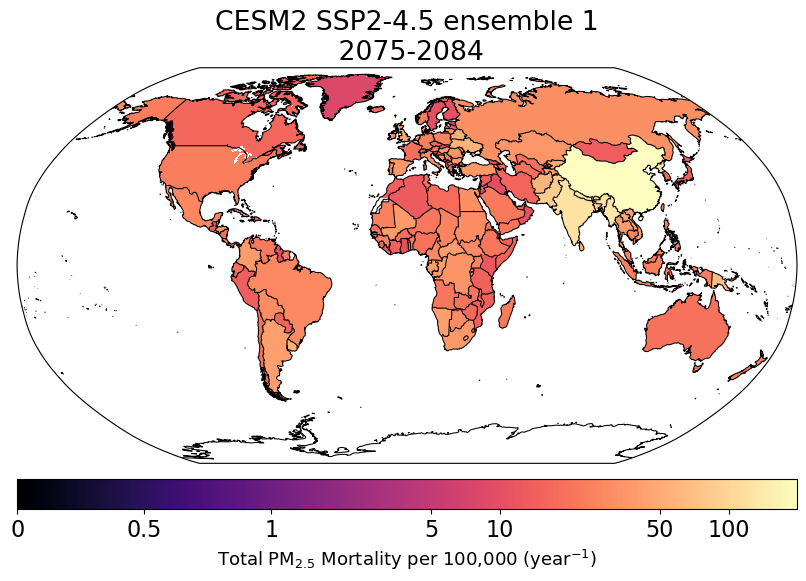

In [5]:
# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/example_workflow/"

model = "CESM2"
scenario = "SSP245_G6"

config = get_scenario_config(model, scenario)

da, first_year, last_year = process_mortality_per_100k(model, scenario, config, 1)

# Convert country level to a global map with lat/lon
da_global = create_global_country_map(da)

# Plotting
plt.rcParams.update({'font.size': 16})
plot_country_level_mortality_per_100k(da_global, model, scenario, first_year, last_year, SAVE_DIR)